In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 7** - Optimising an ML Model with 6 Hyperparameters (6D)

- Optimising an ML model by tuning six hyperparameters 
    - For example learning rate, regularisation strength or number of hidden layers. 

- The function being maximised is the model's performance score (such as accuracy or F1), treated as a black-box function.

**Input** - 6D array  
**Output** - 1D array  
**Optimisation Goal** - Maximise  
**All-time best:** 2.134 at [0.097, 0.417, 0.412, 0.162, 0.308, 0.711] (Week 9)

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 7
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_outputs.npy')

# New data from Week 10 (Function 7)
X_w10_new_point = np.array([0.079216, 0.382295, 0.311153, 0.190364, 0.301736, 0.755824], dtype=np.float64)
Y_w10_new_point = np.array([2.082632791808151], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w10_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w10_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_7/initial_outputs.npy', Y_updated)

print("Updated Inputs (X) - Function 7: ", X_unique)
print("Updated Outputs (Y) - Function 7: ", Y_updated)

Updated Inputs (X) - Function 7:  [[0.001234   0.887611   0.445322   0.221098   0.990123   0.556712  ]
 [0.004352   0.329864   0.487139   0.079703   0.323502   0.982761  ]
 [0.010322   0.277175   0.892712   0.174897   0.395748   0.738827  ]
 [0.017847   0.815326   0.270978   0.212167   0.499065   0.497593  ]
 [0.022693   0.45861    0.588169   0.516538   0.194504   0.964834  ]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.06661051 0.52804507 0.8160952  0.96101714 0.08650933 0.77778822]
 [0.075291   0.40479    0.382733   0.204853   0.437087   0.746748  ]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.079216   0.382295   0.311153   0.190364   0.301736   0.755824  ]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.096872   0.416732   0.412049   0.161576   0.307971   0.710714  ]
 [0.114899   0.037728   0.781258   0.4947     0.114078   0.883059  ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]


## **Output Analysis**

- This week (w10) the output was 2.083 which was lower than last week's (w9) all time best of 2.134.
    - w10's query [0.079, 0.382, 0.311, 0.190, 0.302, 0.756] is close to the W9 best in most dimensions. 
        - The main differences are x3 (0.311 vs 0.412) and x2 (0.382 vs 0.417). 
            - The x3 ceiling at 0.45 held and x3 = 0.311 is well within the safe zone, confirming the constraint is working. 
        
        - The slight drop is likely variance rather than a structural issue.

- **Real-World Implication:** In hyperparameter tuning, small differences in learning rate or regularisation within a high-performing zone produce variable results due to the stochastic nature of model training. 
    - The w10 result being only 0.05 below the best suggests we are in the correct region, this is noise, not a regression.

- **Model Clues and Future Exploration:** Two consecutive results above 2.0 (W9: 2.134, W10: 2.083) confirm a stable high-performance zone. 
    - The risk now is over-exploiting this zone while missing whether there is a higher peak elsewhere. 

- w11 will maintain EI exploitation but widen std slightly to 0.035 and confirm whether the surrounding neighbourhood genuinely has no better configuration.

## **Bayesian Optimisation** - Gaussian Process Regressor

- **Model:** Matern (nu=2.5) + WhiteKernel with Yeo-Johnson transformation.

In [3]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

print('Original Y:', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)
model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20)

model.fit(X_unique, Y_transformed)

Original Y: [0.11990281 0.86440358 1.32634849 0.25791128 0.83814056 1.3649683
 0.51645722 1.71684115 0.00882563 2.08263279 0.00750324 2.1335022
 0.75465759 0.0614243  0.61152553 0.47539552 0.09264495 0.83359509
 0.00701603 0.6044327  0.04211835 0.27489251 0.09541116 0.0735163
 0.01820907 0.56275307 0.2730468  0.0178696  0.10050661 0.2063097
 0.06676325 0.08374657 0.03356494 0.02134252 0.01479818 0.00313433
 0.00270147 0.67514163 0.00377748 0.26840032]
Transformed Y: [-0.47980364  1.1883645   1.51003869  0.07118926  1.16215657  1.52847686
  0.71696681  1.66076723 -1.10491821  1.75174016 -1.11367917  1.76184759
  1.07056736 -0.78350644  0.87768253  0.63735637 -0.61507105  1.15750152
 -1.116916    0.86670596 -0.89562445  0.12648583 -0.60086398 -0.71645761
 -1.04376666  0.79903527  0.12058666 -1.04594844 -0.57498455 -0.11199701
 -0.75361064 -0.66154145 -0.94739678 -1.02373473 -1.06579166 -1.14287964
 -1.14579441  0.96975633 -1.13855618  0.1056172 ]


/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

# **Acqusition Function**

- **Key change:** Widening std to 0.035 (from 0.025). 
    - With two strong consecutive results, there is now enough confidence in the peak region to allow a slightly wider search without the risk of drifting to the x3 > 0.45 failure zone. 
    - The x3 ceiling is retained as a hard constraint. 
    
    - The wider std lets the acquisition function test whether 2.134 is the absolute peak or just one point on a broader high-performance plateau.

- **Limitation:** In 6D, widening std by 0.01 may still produce queries very close to the known best given the high dimensionality. 
    - The key protection is the EI anchoring to 2.134, any candidate must beat that to be selected.

In [4]:
def expected_improvement(X, model, y_max, xi=0.01):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1); mu = mu.reshape(-1, 1)

    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

w9_best = np.array([0.096872, 0.416732, 0.412049, 0.161576, 0.307971, 0.710714])
x_grid = np.random.normal(loc=w9_best, scale=0.035, size=(8500, 6))
x_uniform = np.random.uniform(0, 1, size=(1500, 6))
x_grid = np.vstack([x_grid, x_uniform])

# Hard ceiling: x3 must not exceed 0.45 — empirically validated
x_grid[:, 2] = np.minimum(x_grid[:, 2], 0.45)
x_grid = np.clip(x_grid, 0, 1)

y_max = np.max(Y_transformed)
ei_values = expected_improvement(x_grid, model, y_max, xi=0.01)
next_query = x_grid[np.argmax(ei_values)]

print(f'Best coordinates: {w9_best}')
print(f'Strategic Week 11 Query (Function 7): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}-{next_query[5]:.6f}')

Best coordinates: [0.096872 0.416732 0.412049 0.161576 0.307971 0.710714]
Strategic Week 11 Query (Function 7): 0.177775-0.331618-0.426355-0.198583-0.303865-0.744797


## **Visualisation**

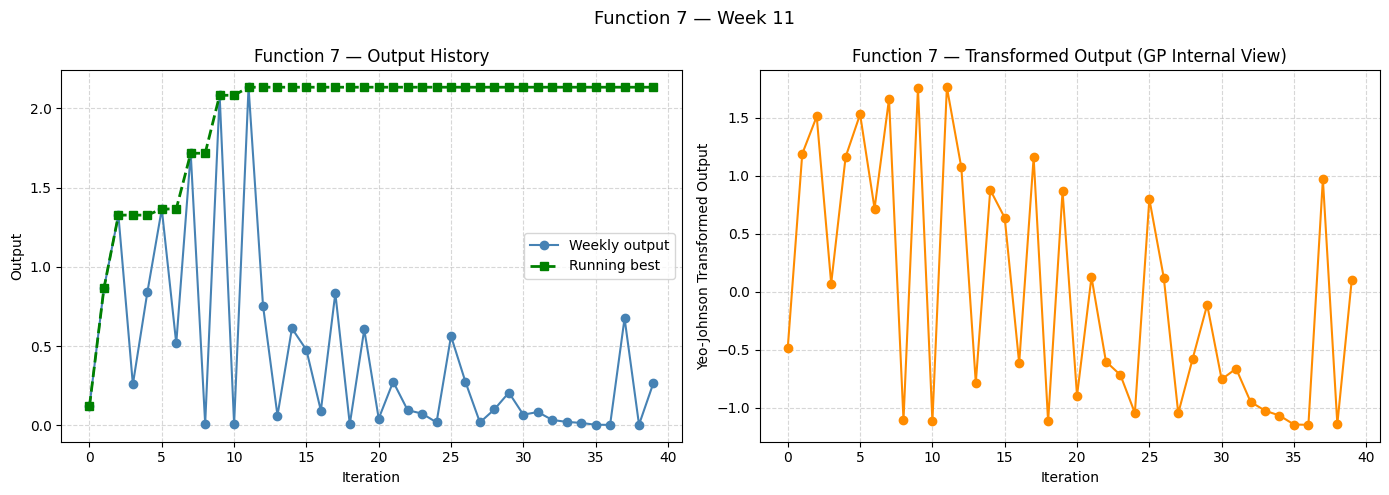

In [6]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].set_title('Function 7 — Output History')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Output')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(Y_transformed, marker='o', color='darkorange', linewidth=1.5)
axes[1].set_title('Function 7 — Transformed Output (GP Internal View)')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Yeo-Johnson Transformed Output')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 7 — Week 11', fontsize=13)
plt.tight_layout()
plt.show()